# ANOVA

In [1]:
# Numerical arrays.
import numpy as np

# Plotting.
import matplotlib.pyplot as plt

# Statistical functions.
import scipy.stats as stats

# Mathematical functions.
import math

# Data frames.
import pandas as pd

# Combinations and permutations.
import itertools as it

## More Samples

In [2]:
# First sample.
sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)

# Second sample.
sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)

# Third sample.
sample_c = np.random.normal(loc=10.0, scale=1.0, size=50)

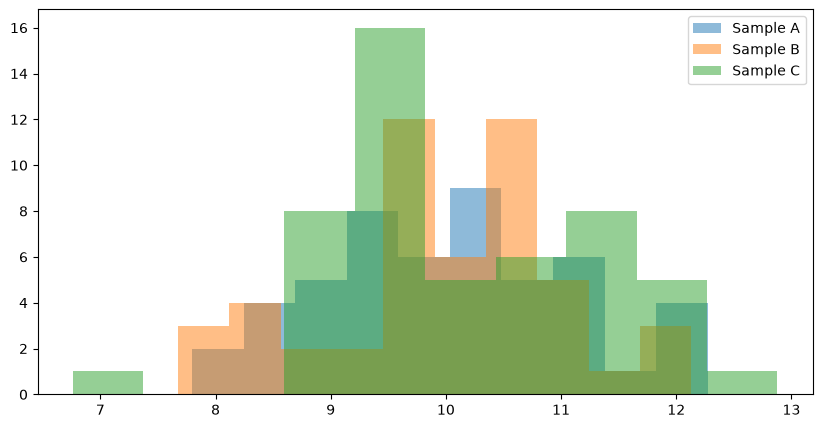

In [3]:
# Create histograms.
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of the first sample.
ax.hist(sample_a, bins=10, alpha=0.5, label='Sample A')

# Histogram of the second sample.
ax.hist(sample_b, bins=10, alpha=0.5, label='Sample B')

# Histogram of the third sample.
ax.hist(sample_c, bins=10, alpha=0.5, label='Sample C')

# Add a legend.
ax.legend();

In [4]:
# Independent samples t-test on sample_a and sample_b.
t_statistic, p_value = stats.ttest_ind(sample_a, sample_b)

# Show.
t_statistic, p_value

(np.float64(-0.005671022309051378), np.float64(0.9954867312947083))

In [5]:
# Independent samples t-test on sample_b and sample_a.
t_statistic, p_value = stats.ttest_ind(sample_b, sample_a)

# Show.
t_statistic, p_value

(np.float64(0.005671022309051378), np.float64(0.9954867312947083))

In [6]:
# Independent samples t-test on sample_a and sample_c.
t_statistic, p_value = stats.ttest_ind(sample_a, sample_c)

# Show.
t_statistic, p_value

(np.float64(-0.8324467624615595), np.float64(0.40718084129858373))

In [7]:
# Independent samples t-test on sample_b and sample_c.
t_statistic, p_value = stats.ttest_ind(sample_b, sample_c)

# Show.
t_statistic, p_value

(np.float64(-0.8450170170707314), np.float64(0.40015964505860896))

## $n$ Samples

In [8]:
# Number of samples.
n = 4

In [9]:
# Show the sample labels.
print(list(range(4)))

[0, 1, 2, 3]


For 4 samples, we can perform 6 t-tests:

[0, 1]  
[0, 2]  
[0, 3]  
[1, 2]  
[1, 3]  
[2, 3]  

In [10]:
# Number of ways of selecting two samples from n.
math.comb(n, 2)

6

In [11]:
# Suppose we had 6 samples.
n = 6
math.comb(n, 2)

15

In [12]:
# Suppose we had 7 samples.
n = 7
math.comb(n, 2)

21

## Type I Errors

In [13]:
def simulate_ttest(alpha=0.05):
    # Geneate a random sample a.
    sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample b.
    sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)
    
    # Perform the t-test.
    _, p_value = stats.ttest_ind(sample_a, sample_b)
    
    # Decide whether to reject the null hypothesis.
    if p_value < alpha:
        return True
    else:
        return False

In [14]:
# Number of rejections.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_ttest():
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

519

In [15]:
def simulate_three_ttest(alpha=0.05):
    # Geneate a random sample a.
    sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample b.
    sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample c.
    sample_c = np.random.normal(loc=10.0, scale=1.0, size=50)
    
    # Perform the t-test one.
    _, p_value0 = stats.ttest_ind(sample_a, sample_b)
    _, p_value1 = stats.ttest_ind(sample_a, sample_c)
    _, p_value2 = stats.ttest_ind(sample_b, sample_c)
    
    # Return the number of null hypothesis rejections.
    no_rejections = 0
    if p_value0 < alpha:
      no_rejections += 1
    if p_value1 < alpha:
      no_rejections += 1
    if p_value2 < alpha:
      no_rejections += 1
    
    return no_rejections

In [16]:
# Set no_rejections to zero.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_three_ttest() > 0:
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

1232

In [17]:
# Generate all pairs of integers from 0 to 6.
for i, j in it.combinations(range(7), 2):
  print(f'{i},{j}')

0,1
0,2
0,3
0,4
0,5
0,6
1,2
1,3
1,4
1,5
1,6
2,3
2,4
2,5
2,6
3,4
3,5
3,6
4,5
4,6
5,6


In [18]:
def simulate_multiple_ttest(no_samples=7, alpha=0.05):
    # Geneate no_samples random samples.
    samples = np.random.normal(size=(no_samples, 50))
    
    # Keep track of nubmer of null hypothesis rejections.
    no_rejections = 0

    # Performs all t-tests.
    for i, j in it.combinations(range(no_samples), 2):
      _, p_value = stats.ttest_ind(samples[i], samples[j])
      if p_value < alpha:
        no_rejections += 1
    
    return no_rejections

In [19]:
# Set no_rejections to zero.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_multiple_ttest() > 0:
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

4404

## ANOVA

https://statistics.laerd.com/spss-tutorials/one-way-anova-using-spss-statistics.php  

In [20]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

In [21]:
# Create data frame.
df = pd.DataFrame({'Beginner': beginner, 'Intermediate': intermediate, 'Advanced': advanced})

# Show.
df

,Beginner,Intermediate,Advanced
0,27.194891,25.659851,28.971723
1,26.455240,20.947921,23.386816
2,24.028823,21.040665,24.106494
3,29.153308,30.920909,24.460374
4,30.843991,22.984231,25.534987
5,30.539476,20.425683,21.482543
6,28.124823,30.357679,31.408127
7,27.067194,27.008714,23.327789
8,26.096541,27.248115,19.393670
9,27.244955,25.598950,19.034746


In [22]:
# Describe.
df.describe()

,Beginner,Intermediate,Advanced
count,10.000000,10.000000,10.000000
mean,27.674924,25.219272,24.110727
std,2.073491,3.804202,3.874313
min,24.028823,20.425683,19.034746
25%,26.608228,21.526556,21.943854
50%,27.219923,25.629400,23.746655
75%,28.896187,27.188265,25.266334
max,30.843991,30.920909,31.408127


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html  

In [23]:
# Perform ANOVA.
f_statistic, p_value = stats.f_oneway(df['Beginner'], df['Intermediate'], df['Advanced'])

# Show.
f_statistic, p_value

(np.float64(2.9546546938770026), np.float64(0.0691205905940726))

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html

In [24]:
# Tukey's HSD.
res = stats.tukey_hsd(df['Beginner'], df['Intermediate'], df['Advanced'])

# Show.
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      2.456     0.248    -1.265     6.177
 (0 - 2)      3.564     0.062    -0.157     7.285
 (1 - 0)     -2.456     0.248    -6.177     1.265
 (1 - 2)      1.109     0.743    -2.612     4.829
 (2 - 0)     -3.564     0.062    -7.285     0.157
 (2 - 1)     -1.109     0.743    -4.829     2.612



## Presenting the Data

In [25]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

# Concatenate arrays.
data = np.concatenate([beginner, intermediate, advanced])

# Show.
data

array([27.2374001 , 29.15360419, 34.34921458, 29.3736154 , 23.55490418,
       29.26372036, 29.72225902, 29.57483235, 31.09960749, 36.17103221,
       24.95330423, 20.06233068, 21.56155746, 26.18114693, 24.34317036,
       22.75178109, 24.49239301, 22.78597179, 27.21681166, 22.49971527,
       19.8240887 , 23.56163886, 26.84144156, 20.83699616, 23.52394749,
       16.0008661 , 23.62786294, 26.36569445, 26.22936978, 20.75741487])

In [26]:
# Create the labels.
labels = ['Beginner'] * 10 + ['Intermediate'] * 10 + ['Advanced'] * 10

# Show.
labels

['Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced']

In [27]:
# Create data frame.
df = pd.DataFrame({'Course': labels, 'Time': data})

# Show.
df

,Course,Time
0,Beginner,27.237400
1,Beginner,29.153604
2,Beginner,34.349215
3,Beginner,29.373615
4,Beginner,23.554904
5,Beginner,29.263720
6,Beginner,29.722259
7,Beginner,29.574832
8,Beginner,31.099607
9,Beginner,36.171032


In [28]:
# Pull the groups out.
b_times = df[df['Course'] == 'Beginner']['Time']
i_times = df[df['Course'] == 'Intermediate']['Time']
a_times = df[df['Course'] == 'Advanced']['Time']

# Perform ANOVA.
f, p = stats.f_oneway(b_times, i_times, a_times)

# Show.
f, p

(np.float64(16.07934601641557), np.float64(2.518605863492499e-05))

In [29]:
# Tukey's HSD.
res = stats.tukey_hsd(b_times, i_times, a_times)

# Show.
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      6.265     0.000     2.844     9.687
 (0 - 2)      7.193     0.000     3.772    10.614
 (1 - 0)     -6.265     0.000    -9.687    -2.844
 (1 - 2)      0.928     0.781    -2.494     4.349
 (2 - 0)     -7.193     0.000   -10.614    -3.772
 (2 - 1)     -0.928     0.781    -4.349     2.494



## The F Statistic using numpy

https://en.wikipedia.org/wiki/F-test#One-way_analysis_of_variance

In [30]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

In [31]:
# Calculate the means.
beginner_mean = beginner.mean()
intermediate_mean = intermediate.mean()
advanced_mean = advanced.mean()

In [32]:
# Y(bar)_i from the formula.
Y_i = np.array([beginner_mean, intermediate_mean, advanced_mean])

# Show.
Y_i

array([27.72387299, 23.33335837, 25.80721761])

In [33]:
# Y(bar) from the formula.
Y = np.concatenate([beginner, intermediate, advanced]).mean()

# Show.
Y

np.float64(25.62148299004162)

In [34]:
# Before the sum of squares.
Y_i - Y

array([ 2.10239   , -2.28812462,  0.18573462])

In [35]:
# Calculate the sum of squares between.
(Y_i - Y)**2

array([4.4200437 , 5.23551426, 0.03449735])

In [36]:
# Size of the samples.
n_i = np.array([beginner.size, intermediate.size, advanced.size])

# Show.
n_i

array([10, 10, 10])

In [37]:
# Number of groups.
K = 3

In [38]:
# From the formula.
n_i * (Y_i - Y)**2

array([44.20043702, 52.35514258,  0.34497348])

In [39]:
# From the formula.
(n_i * (Y_i - Y)**2).sum()

np.float64(96.90055308359224)

In [40]:
# From the formula.
(n_i * (Y_i - Y)**2).sum() / (K - 1)

np.float64(48.45027654179612)

In [41]:
# Numerator.
numerator = (n_i * (Y_i - Y)**2).sum() / (K - 1)

In [42]:
# The total number of values.
N = n_i.sum()

# Show.
N

np.int64(30)

In [43]:
# From the formula.
less_means = np.concatenate([beginner - beginner_mean, intermediate - intermediate_mean, advanced - advanced_mean])

# Show.
less_means

array([ 0.29814037,  0.85452922, -0.03629621, -2.47319601,  1.39362831,
        3.57552083, -6.95792287,  3.66144053,  1.76060898, -2.07645316,
       -0.16121586,  0.69176377, -1.13184693, -1.67119554,  1.06315473,
       -0.36746305, -0.9575464 ,  3.09996801, -2.04155721,  1.47593848,
       -1.13227752, -0.25615902, -2.08952489,  2.40302446, -0.61191665,
        0.45768913,  0.12454294,  3.51696598, -2.23414739, -0.17819704])

In [44]:
# From the formula.
np.sum(less_means**2)

np.float64(143.09074714796574)

In [45]:
# Denominator.
denominator = np.sum(less_means**2) / (N - K)

# Show.
denominator

np.float64(5.299657301776509)

In [46]:
# My F statistic calculation.
F = numerator / denominator

# Show.
F

np.float64(9.142152743641557)

In [47]:
# Calculate F using scipy.
stats.f_oneway(beginner, intermediate, advanced)

F_onewayResult(statistic=np.float64(9.142152743641558), pvalue=np.float64(0.0009292160684195365))

## End